In [1]:
import pandas as pd 
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

## Freight cost is the total charge paid to a carrier or logistics company for transporting goods from one location to another (for example, from a supplier/vendor's warehouse to a company's fulfillment center).

In [8]:
conn = sqlite3.connect("../data/inventory.db")

In [9]:
tables = pd.read_sql_query("Select name from sqlite_master where type = 'table'",conn)

In [10]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


### ALL Tables

In [16]:
for table in tables['name']:
    print("="*50)    
    print("Table : " ,table)
    print("="*50)
    df = pd.read_sql_query(f"Select * from {table} limit 5",conn)
    print(df)
    print()

Table :  purchases
           InventoryId  Store  Brand                   Description   Size  \
0    69_MOUNTMEND_8412     69   8412     Tequila Ocho Plata Fresno  750mL   
1     30_CULCHETH_5255     30   5255  TGI Fridays Ultimte Mudslide  1.75L   
2    34_PITMERDEN_5215     34   5215  TGI Fridays Long Island Iced  1.75L   
3  1_HARDERSFIELD_5255      1   5255  TGI Fridays Ultimte Mudslide  1.75L   
4    76_DONCASTER_2034     76   2034     Glendalough Double Barrel  750mL   

   VendorNumber                   VendorName  PONumber      PODate  \
0           105  ALTAMAR BRANDS LLC               8124  2023-12-21   
1          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
2          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
3          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
4           388  ATLANTIC IMPORTING COMPANY       8169  2023-12-24   

  ReceivingDate InvoiceDate     PayDate  PurchasePrice  Quantity  Dollars  \
0    2024-01-02  202

### Vendor Data

In [17]:
vendor_df = pd.read_sql_query("select * from vendor_invoice",conn)
vendor_df

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None
...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,None
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,None
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,None
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,None


In [20]:
vendor_df.columns

Index(['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate',
       'PayDate', 'Quantity', 'Dollars', 'Freight', 'Approval'],
      dtype='object')

In [29]:
v1 = vendor_df[['VendorNumber', 'PONumber', 'Quantity', 'Dollars', 'Freight']].corr()

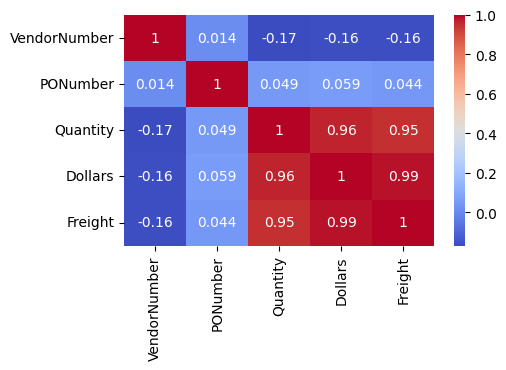

In [36]:
plt.figure(figsize=(5,3))
sns.heatmap(v1,annot=True, cmap='coolwarm')
plt.show()

### Add column for vendor pay freight per quantity

In [37]:
vendor_df['freight_per_unit'] = vendor_df['Freight'] / vendor_df['Quantity']

In [38]:
vendor_df.sample(3)

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,freight_per_unit
3957,17032,JEWELL TOWNE VINEYARDS,2024-09-26,12133,2024-09-16,2024-11-13,106,908.96,4.73,None,0.044623
1854,6215,MOONLIGHT MEADERY,2024-05-16,9991,2024-04-28,2024-06-09,120,1081.68,5.84,None,0.048667
1085,9751,VINEDREA WINES LLC,2024-03-21,9128,2024-02-28,2024-04-22,13,295.36,1.42,None,0.109231


In [40]:
low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)
print(f"Low Quantity = {low_quantity}, High Quantity = {high_quantity}")

Low Quantity = 83.0, High Quantity = 5100.5


In [42]:
vendor_df.loc[vendor_df['Quantity']<low_quantity,'freight_per_unit'].mean()

np.float64(0.09489854253138316)

In [46]:
vendor_df.loc[vendor_df['Quantity']>high_quantity,'freight_per_unit'].mean()

np.float64(0.049077654690759046)

In [50]:
vendor_df.describe().round()

,VendorNumber,PONumber,Quantity,Dollars,Freight,freight_per_unit
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0
min,2.0,8106.0,1.0,4.0,0.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0


## Splitting Column

In [51]:
X = vendor_df[['Quantity','Dollars']]
y = vendor_df['Freight']

### Creating Model

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2 , random_state=42)

In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [57]:
m1 = LinearRegression()
m1.fit(X_train , y_train)

m2 = DecisionTreeRegressor(random_state=42)
m2.fit(X_train , y_train)

m3 = RandomForestRegressor(random_state=42)
m3.fit(X_train , y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [69]:
def evaluate_model(model , X_test , y_test , model_name):
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test,preds) * 100

    print(f"\n{model_name} Performance:")
    print(f"mae : {mae:.2f}")
    print(f"rmse : {rmse:.2f}")
    print(f"r2 : {r2:.2f}%")

In [70]:
evaluate_model(m1 , X_test , y_test, "Linear Regression")
evaluate_model(m2 , X_test , y_test, "Decision Tree Regression")
evaluate_model(m3 , X_test , y_test, "Random Forest Regression")


Linear Regression Performance:
mae : 24.46
rmse : 15482.52
r2 : 97.00%

Decision Tree Regression Performance:
mae : 33.87
rmse : 33306.53
r2 : 93.55%

Random Forest Regression Performance:
mae : 27.65
rmse : 19215.83
r2 : 96.28%


### We can set hyperperameter to get best accuracy and after doing that all we get best model as Linear Regression

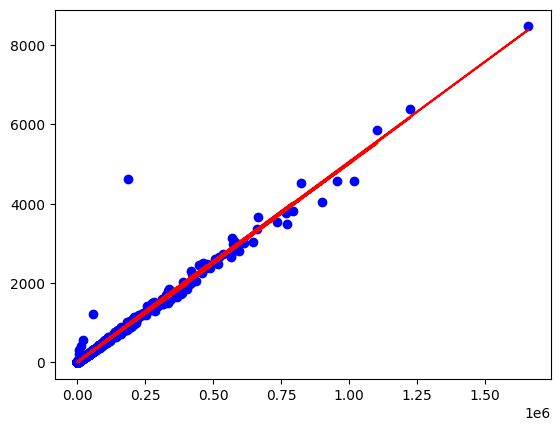

In [88]:
plt.scatter(X_test['Dollars'] , y_test, color='blue')
plt.plot(X_test['Dollars'], m1.predict(X_test), color = 'Red')
plt.show()

### unseen data

In [109]:
input_data = {
    "Quantity" : [455,760],
    "Dollars" : [18500,9000]
}
df = pd.DataFrame(input_data)

In [110]:
m1.predict(df)

array([101.15880159,  51.01434686])